# Hospital Operations Intelligence Platform

## Notebook 08: SHAP Explainability

### Business objective

Black-box risk predictions are not acceptable in healthcare operations.
This notebook explains global model behavior and individual patient predictions,
then saves auditable visual reports.

### Outputs

- Global readmission feature importance
- SHAP summary plot
- Individual patient waterfall plot
- Patient-level top risk factors
- `reports/SHAP_Report.pdf`

## 1. Imports, model, and explanation sample

In [1]:
from pathlib import Path
import sys

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
sys.path.insert(0, str(ROOT / "src"))

RAW = ROOT / "datasets" / "raw"
INTERIM = ROOT / "datasets" / "interim"
PROCESSED = ROOT / "datasets" / "processed"
MODELS = ROOT / "models"
REPORTS = ROOT / "reports"
EXPERIMENT_MODELS = MODELS / "experiments"
EXPERIMENT_REPORTS = REPORTS / "experiments"
for folder in [INTERIM, PROCESSED, MODELS, REPORTS, EXPERIMENT_MODELS, EXPERIMENT_REPORTS]:
    folder.mkdir(parents=True, exist_ok=True)

print(f"Project root: {ROOT}")

import warnings
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
from matplotlib.backends.backend_pdf import PdfPages

warnings.filterwarnings("ignore")
SHAP_DIR = EXPERIMENT_REPORTS / "shap"
SHAP_DIR.mkdir(parents=True, exist_ok=True)

Project root: c:\Users\HP\Desktop\Hospital OP Inteligent sys


In [2]:
data_path = INTERIM / "notebook_model_features.csv"
model_path = EXPERIMENT_MODELS / "readmission_notebook.pkl"
data = pd.read_csv(data_path)
pipeline = joblib.load(model_path)
preprocessor = pipeline.named_steps["prep"]
estimator = pipeline.named_steps["model"]
sample = data.sample(min(250, len(data)), random_state=42)
X = sample[list(preprocessor.feature_names_in_)]
X_transformed = preprocessor.transform(X)
feature_names = preprocessor.get_feature_names_out()

if hasattr(estimator, "estimators_"):
    estimator_for_shap = estimator.estimators_[0]
else:
    estimator_for_shap = estimator

print("Model:", type(estimator).__name__)
print("Explanation sample:", X.shape)

Model: LogisticRegression
Explanation sample: (250, 15)


## 2. Generate SHAP values

In [3]:
try:
    explainer = shap.Explainer(estimator_for_shap, X_transformed[:50])
    explanation = explainer(X_transformed)
except Exception:
    prediction_function = (
        estimator_for_shap.predict_proba
        if hasattr(estimator_for_shap, "predict_proba")
        else estimator_for_shap.predict
    )
    explainer = shap.Explainer(prediction_function, X_transformed[:50])
    explanation = explainer(X_transformed[:100])

values = np.asarray(explanation.values)
if values.ndim == 3:
    values = values[:, :, -1]
    explanation.values = values
print("SHAP matrix:", values.shape)

SHAP matrix: (250, 23)


## 3. Global feature importance and summary plot

,feature,mean_abs_shap
0,numeric__los_days,0.265305
5,numeric__haemoglobin,0.171306
2,numeric__charlson_index,0.158254
9,numeric__disease_severity_score,0.135028
15,categorical__ward_type_General,0.116515
11,numeric__patient_complexity_index,0.105550
17,categorical__ward_type_ICU,0.082454
7,numeric__previous_admissions,0.065938
13,categorical__admit_type_Emergency,0.060623
1,numeric__num_procedures,0.055291


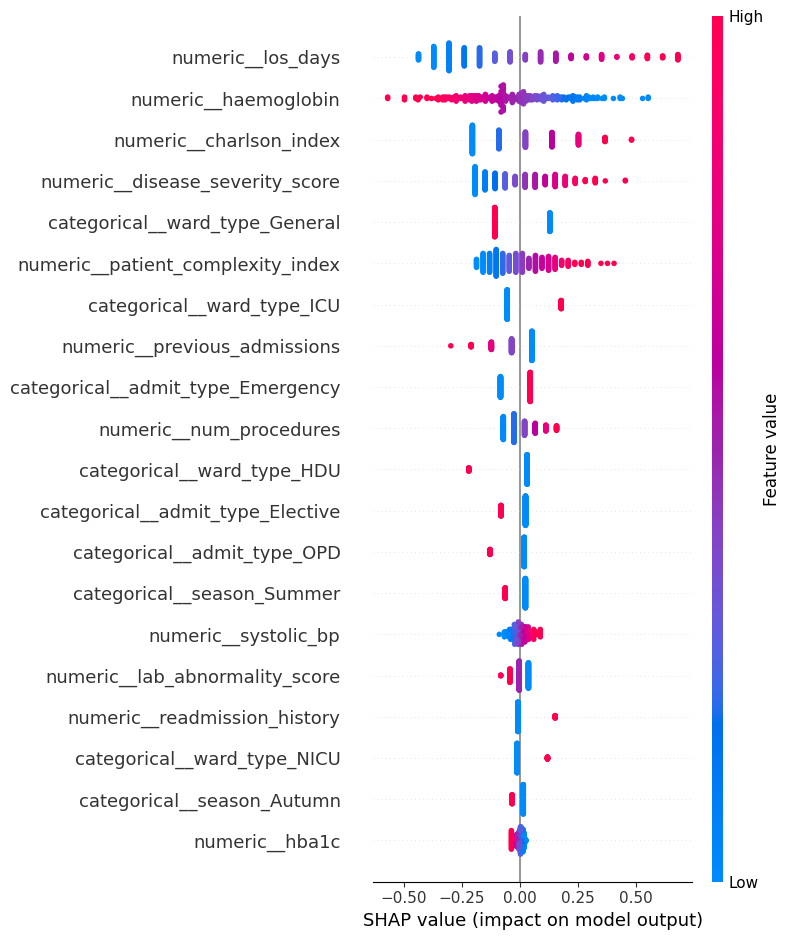

In [4]:
importance = pd.DataFrame(
    {
        "feature": feature_names,
        "mean_abs_shap": np.abs(values).mean(axis=0),
    }
).sort_values("mean_abs_shap", ascending=False)
display(importance.head(20))

plt.figure()
shap.summary_plot(
    values,
    X_transformed[: len(values)],
    feature_names=feature_names,
    show=False,
    max_display=20,
)
plt.tight_layout()
plt.savefig(SHAP_DIR / "readmission_summary.png", dpi=180, bbox_inches="tight")
plt.show()

## 4. Individual prediction explanation

Patient: 998f23f6-8890-42af-b029-5a86954e3953
Readmission probability: 68.4%


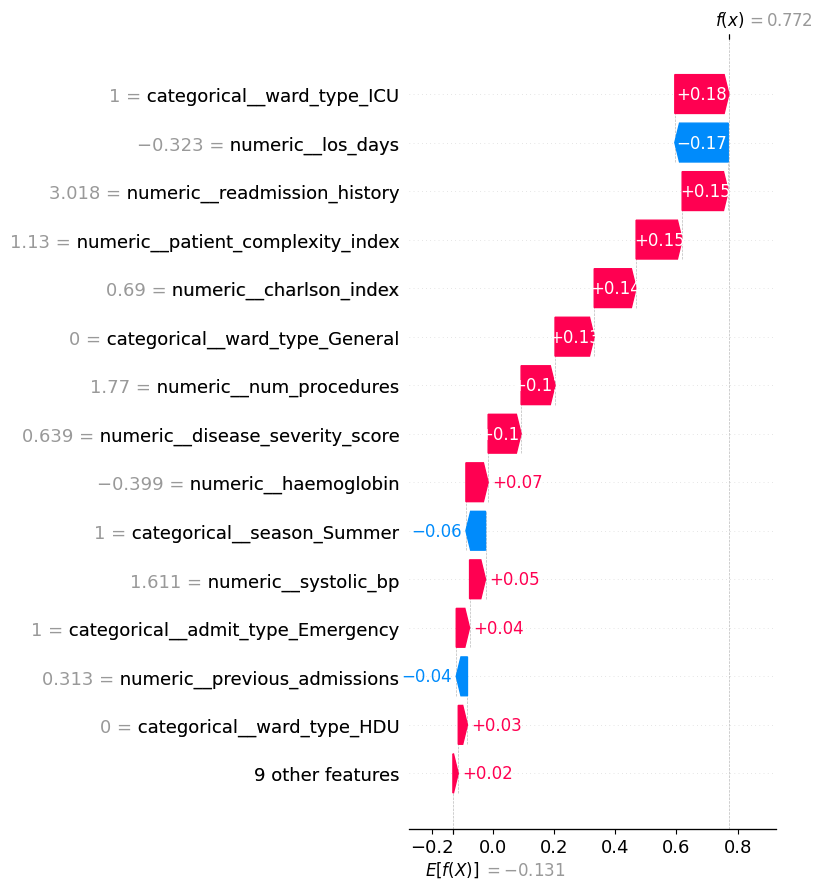

In [5]:
patient_position = 0
patient_id = sample.iloc[patient_position]["patient_id"]
patient_probability = pipeline.predict_proba(
    X.iloc[[patient_position]]
)[0, 1]
print("Patient:", patient_id)
print("Readmission probability:", f"{patient_probability:.1%}")

patient_explanation = shap.Explanation(
    values=values[patient_position],
    base_values=np.asarray(explanation.base_values)[patient_position],
    data=(
        X_transformed[patient_position].toarray().ravel()
        if hasattr(X_transformed[patient_position], "toarray")
        else np.asarray(X_transformed[patient_position]).ravel()
    ),
    feature_names=list(feature_names),
)
shap.plots.waterfall(patient_explanation, max_display=15, show=False)
plt.tight_layout()
plt.savefig(SHAP_DIR / "patient_waterfall.png", dpi=180, bbox_inches="tight")
plt.show()

## 5. Patient-level risk factors

In [6]:
positive = np.where(values > 0, values, -np.inf)
top_index = positive.argmax(axis=1)
patient_factors = pd.DataFrame(
    {
        "patient_id": sample.iloc[: len(values)]["patient_id"].to_numpy(),
        "top_risk_factor": feature_names[top_index],
        "factor_contribution": values[np.arange(len(values)), top_index],
    }
)
display(patient_factors.head(20))

,patient_id,top_risk_factor,factor_contribution
0,998f23f6-8890-42af-b029-5a86954e3953,categorical__ward_type_ICU,0.176821
1,8fab09fd-0ad6-46b4-a729-d6455d4f4148,categorical__ward_type_General,0.128132
2,736cbfc0-d9e4-410e-a777-43cf2d030842,numeric__haemoglobin,0.285353
3,0fb84a22-439c-4f9e-8fd6-ccb8153bf89d,numeric__haemoglobin,0.227355
4,3f8be711-d02a-429d-bf87-1fec50bd049b,numeric__los_days,0.350647
5,d8100f41-153f-48c1-9c58-c15250eb9aeb,numeric__previous_admissions,0.050609
6,2b8652f0-1a44-48f5-a9f1-139ce77ee975,categorical__ward_type_General,0.128132
7,05a3f69d-4324-4fe0-9e93-30b81063047a,numeric__haemoglobin,0.246688
8,2b5b46a2-0b6e-457e-9c8b-7f0c12d432c5,numeric__haemoglobin,0.285353
9,e687dc79-1673-4f42-af37-e2d41b469329,numeric__charlson_index,0.136977


## 6. Save explainability outputs and PDF

In [7]:
importance.to_csv(EXPERIMENT_REPORTS / "readmission_shap_importance.csv", index=False)
patient_factors.to_csv(EXPERIMENT_REPORTS / "patient_shap_explanations.csv", index=False)

with PdfPages(EXPERIMENT_REPORTS / "SHAP_Report.pdf") as pdf:
    for image_path, title in [
        (SHAP_DIR / "readmission_summary.png", "Global readmission drivers"),
        (SHAP_DIR / "patient_waterfall.png", "Individual patient explanation"),
    ]:
        image = plt.imread(image_path)
        fig, axis = plt.subplots(figsize=(11.7, 8.3))
        axis.imshow(image)
        axis.axis("off")
        axis.set_title(title, fontsize=16)
        pdf.savefig(fig, bbox_inches="tight")
        plt.close(fig)

print("Saved:", EXPERIMENT_REPORTS / "SHAP_Report.pdf")

Saved: c:\Users\HP\Desktop\Hospital OP Inteligent sys\reports\experiments\SHAP_Report.pdf


## Business conclusions

- Length of stay, comorbidity, haemoglobin, severity, and patient complexity are
  leading global readmission drivers in the current model.
- A global SHAP chart does not explain every individual patient; use the
  patient-level waterfall for case review.
- SHAP explains model behavior, not medical causality.
- Explanations and predictions must be audited for drift, bias, and data quality
  before any operational deployment.

These notebook findings feed the Explainable AI page in Streamlit.